In [97]:
import numpy as np
import matplotlib.pyplot as plt

import IPython
import os
import zipfile

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras.models import Model
from keras.layers import Conv2D, Input, Dropout, BatchNormalization, MaxPool2D, GlobalAveragePooling2D
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import AdamW
from keras.callbacks import TensorBoard, ModelCheckpoint

import scipy.io as sio

In [2]:
data_dir = "/mnt/e/Deep Learning/data"
dataset_speech_path = os.path.join(data_dir, "dataset_speech")

os.makedirs(dataset_speech_path, exist_ok=True)

In [3]:
# import tensorflow as tf

# data_path = tf.keras.utils.get_file(
#     fname="mini_speech_commands.zip",
#     origin="https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
#     cache_dir="/mnt/e/Deep Learning/data",
#     cache_subdir="dataset_speech",
#     extract=True
# )

# print(data_path)

In [4]:
os.listdir(dataset_speech_path)

['mini_speech_commands', 'mini_speech_commands.zip', '__MACOSX']

In [5]:
# with zipfile.ZipFile(os.path.join(dataset_speech_path, os.listdir(dataset_speech_path)[0]), 'r') as f:
#     f.extractall(path=dataset_speech_path)

In [6]:
os.listdir(dataset_speech_path)

['mini_speech_commands', 'mini_speech_commands.zip', '__MACOSX']

In [7]:
mini_speech_dataset_path = os.path.join(dataset_speech_path, os.listdir(dataset_speech_path)[0])
mini_speech_dataset_path

'/mnt/e/Deep Learning/data/dataset_speech/mini_speech_commands'

In [8]:
classes_name = os.listdir(mini_speech_dataset_path)
classes_name

['down', 'go', 'left', 'no', 'README.md', 'right', 'stop', 'up', 'yes']

In [9]:
for name_clc in classes_name:
    dir = os.path.join(mini_speech_dataset_path, name_clc)
    
    if os.path.isdir(dir):
        print(f'Number of audio file for class: {name_clc} is: {len([file for file in os.listdir(dir) if file.endswith(".wav")])}')

Number of audio file for class: down is: 1000
Number of audio file for class: go is: 1000
Number of audio file for class: left is: 1000
Number of audio file for class: no is: 1000
Number of audio file for class: right is: 1000
Number of audio file for class: stop is: 1000
Number of audio file for class: up is: 1000
Number of audio file for class: yes is: 1000


In [10]:
sample_path = "/mnt/e/Deep Learning/data/dataset_speech/mini_speech_commands/go/0a9f9af7_nohash_0.wav"

sample_rate, data = sio.wavfile.read(sample_path)
print(f"Sample rate is: {sample_rate}")

Sample rate is: 16000


In [69]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(mini_speech_dataset_path, 
                                                               batch_size = 64,
                                                               validation_split = 0.2,
                                                               seed = 42,
                                                               output_sequence_length = sample_rate,
                                                               subset = 'both'
                                                               )

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.


In [70]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [71]:
for data, labels in train_ds.take(1):
    audio = data[1]
    label = labels[1]
    print(audio.shape)
    print(train_ds.class_names[label.numpy()])

(16000, 1)
yes


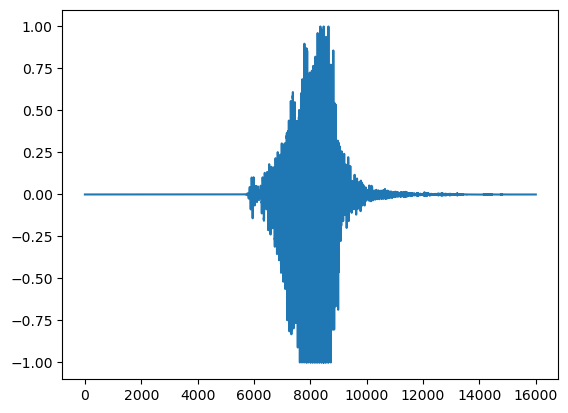

In [72]:
plt.plot(audio)

In [73]:
IPython.display.Audio(tf.reshape(audio, shape=(-1,)), rate=sample_rate)

In [74]:
train_ds = train_ds.map(
    lambda x, y: (tf.reshape(x, (-1, sample_rate)), y)
)

In [75]:
data, labels = next(iter(train_ds))
print(data.shape)
print(labels.shape)

(64, 16000)
(64,)


In [76]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [77]:
tf.data.experimental.cardinality(test_ds).numpy()

np.int64(13)

In [78]:
tf.data.experimental.cardinality(train_ds).numpy()

np.int64(100)

In [79]:
tf.data.experimental.cardinality(val_ds).numpy()

np.int64(12)

In [80]:
audio.shape

TensorShape([16000, 1])

/tmp/ipykernel_180502/3212773697.py:1: MatplotlibDeprecationWarning: Passing the NFFT parameter of specgram() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.specgram(tf.squeeze(audio), sample_rate)
/tmp/ipykernel_180502/3212773697.py:1: UserWarning: Only one segment is calculated since parameter NFFT (=16000) >= signal length (=16000).
  plt.specgram(tf.squeeze(audio), sample_rate)


(array([[1.92890373e-02],
        [3.81270927e-02],
        [3.67916370e-02],
        ...,
        [1.44424823e-06],
        [1.51287261e-06],
        [7.64885918e-07]], shape=(8001, 1)),
 array([0.00000e+00, 1.25000e-04, 2.50000e-04, ..., 9.99750e-01,
        9.99875e-01, 1.00000e+00], shape=(8001,)),
 array([4000.]),
 <matplotlib.image.AxesImage at 0x7af59cf99150>)

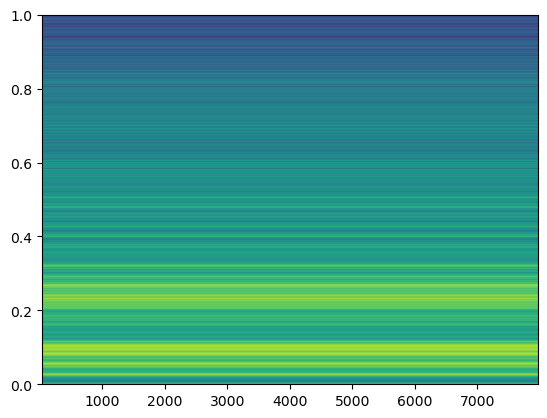

In [81]:
plt.specgram(tf.squeeze(audio), sample_rate)

In [82]:
spect = tf.signal.stft(tf.squeeze(audio), frame_length=255, frame_step=128)

In [83]:
def get_spectogram(audio):
    if audio.shape[-1] == 1:
        audio = tf.squeeze(audio, axis=-1)

    # assert len(audio.shape) != 3

    spect = tf.signal.stft(
        audio,
        frame_length=255,
        frame_step=128
    )

    spect = tf.abs(spect)
    spect = spect[..., tf.newaxis]

    return spect

In [84]:
audio.shape

TensorShape([16000, 1])

In [85]:
get_spectogram(audio).shape

TensorShape([124, 129, 1])

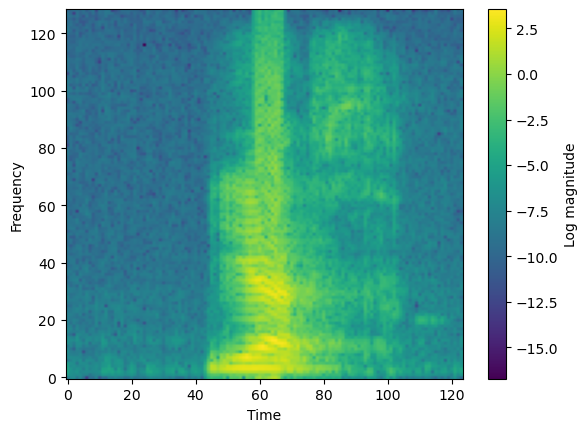

In [86]:
spectrogram = get_spectogram(audio=audio)

plt.imshow(
    np.log(tf.squeeze(tf.transpose(spectrogram)) + 1e-10),
    aspect="auto",
    origin="lower"
)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="Log magnitude")

In [87]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [88]:
train_ds = train_ds.map(lambda x, y: (get_spectogram(x), y))

In [89]:
spect_batch, label_batch = next(iter(train_ds))
print(spect_batch.shape)

(64, 124, 129, 1)


In [90]:
val_ds = val_ds.map(lambda x, y: (get_spectogram(x), y))
test_ds = test_ds.map(lambda x, y: (get_spectogram(x), y))

In [91]:
train_spectrogram_ds = train_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [92]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 124, 129, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [93]:
print(train_spectrogram_ds.element_spec)

(TensorSpec(shape=(None, 124, 129, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [94]:
for x, y in train_ds.take(1):
    print(x.shape)

(64, 124, 129, 1)


In [95]:
train_spectrograms = train_spectrogram_ds.map(lambda x, y: x).unbatch()

norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(train_spectrograms)

In [102]:
input = Input(shape=(124, 129, 1))
x = Conv2D(32, 3, activation='relu', padding='same')(input) #(124, 129, 32)
x = Conv2D(64, 3, activation='relu', padding='same')(x) #(124, 129, 64)
x = MaxPool2D()(x)  #(62, 64, 64)
x = Dropout(0.2)(x)

x = GlobalAveragePooling2D()(x) #(64,)

x = Dense(128, activation='relu')(x)    #(128, )
x = Dropout(0.2)(x)

output = Dense(len(classes_name) - 1)(x)
               
model = Model(input, output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 124, 129, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 124, 129, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 124, 129, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 62, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,168 (110.03 KB)

 Trainable params: 28,168 (110.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = AdamW(learning_rate=0.001)
loss_obj = SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

Num_epochs = 20

train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []

for epoch in range(Num_epochs):

    print(f"Epoch {epoch + 1}/{Num_epochs}")

    train_loss_epoch = []
    val_loss_epoch = []

    # Reset metrics at the beginning of each epoch
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()

    # Training loop
    for x, y in train_spectrogram_ds:

        with tf.GradientTape() as tape:
            logits = model(x, training=True)
            train_loss = loss_obj(y, logits)

        gradients = tape.gradient(train_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_loss_epoch.append(train_loss.numpy())
        train_acc_metric.update_state(y, logits)

    # Validation loop
    for x, y in val_spectrogram_ds:

        logits = model(x, training=False)
        val_loss = loss_obj(y, logits)

        val_loss_epoch.append(val_loss.numpy())
        val_acc_metric.update_state(y, logits)

    # Store epoch results
    train_losses.append(np.mean(train_loss_epoch))
    val_losses.append(np.mean(val_loss_epoch))

    train_accuracy.append(train_acc_metric.result().numpy())
    val_accuracy.append(val_acc_metric.result().numpy())

    # Print epoch results
    print(
        f"Train Loss: {train_losses[-1]:.4f} | "
        f"Train Acc: {train_accuracy[-1]:.4f} | "
        f"Val Loss: {val_losses[-1]:.4f} | "
        f"Val Acc: {val_accuracy[-1]:.4f}"
    )